In [2]:
import pandas as pd
from pandas import Series, DataFrame
from numpy import *

file_path = 'G:/dataset/alibaba_clusterdata_v2018/machine_usage.csv'
data = pd.read_csv(file_path, names=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'])
print(data)

                a       b     c   d     e    f      g      h   i
0          m_1932  386640  41.0  92   NaN  NaN  43.04  33.08   5
1          m_1932  386670  43.0  92   NaN  NaN  43.04  33.08   5
2          m_1932  386690  44.0  92   NaN  NaN  43.05  33.08   5
3          m_1932  386800  46.0  92   NaN  NaN  43.05  33.08   3
4          m_1932  386930  44.0  93   NaN  NaN  43.05  33.09   4
...           ...     ...   ...  ..   ...  ...    ...    ...  ..
246934815  m_1932  655420  45.0  93  1.88  0.0  48.73  37.73   4
246934816  m_1932  655580  54.0  96  0.49  1.0  48.74  37.73   7
246934817  m_1932  655720  39.0  94  1.97  1.0  48.74  37.73  10
246934818  m_1932  655890  36.0  93  2.89  1.0  48.74  37.74   6
246934819  m_1932  655900  40.0  93  2.27  1.0  48.74  37.74   6

[246934820 rows x 9 columns]


In [18]:
import pandas as pd
from pandas import Series, DataFrame
from numpy import *
import json

#存放文件名称
file_list=['h'] 
result_list=[]
for file_name in file_list:
    with open('E:\google\machine_events\\'+file_name,'r') as file:
        for line in file:
            dict=line.split('\n')
            json_data=json.loads(dict[0])
            result_list.append(json_data)
df=pd.DataFrame(result_list)
#筛除指定数据
df=df[df['capacity'].notna()]
#创造新的两列，便于读取
df['cpus'] = df['capacity'].apply(lambda x: str(x['cpus']))
df['memory'] = df['capacity'].apply(lambda x: str(x['memory']))
#转换‘time’数据类型
df['time']=df['time'].astype('int64',errors='ignore')

s = []
ms = [864600000000,
868200000000,
871800000000,
875400000000,
879000000000,
882600000000,
886200000000,
889800000000,
893400000000,
897000000000,
900600000000,
904200000000,
907800000000,
911400000000,
915000000000,
918600000000,
922200000000,
925800000000,
929400000000,
933000000000,
936600000000,
940200000000,
943800000000,
947400000000,
951000000000]

for i in range(24):
    item = df[df['time']>=ms[i]]
    item = item[item['time']<ms[i+1]]
    item = item.iloc[:,6].values.tolist()
    item = list(map(float,item))
    s.append(mean(item))

print(s)

[0.9974365234375, 0.9978966346153846, 0.9841859879032258, 0.9795619419642857, 0.9150752314814815, 0.9389143318965517, 0.9587823275862069, 0.9675611413043478, 0.9978412828947368, 0.773169948630137, 0.7781960227272727, 0.8376608455882353, 0.7806438577586207, 0.8119032118055556, 0.818426724137931, 0.849609375, 0.7818127648305084, 0.9832240513392857, 0.7868024553571429, 0.9986552254098361, 0.9690193965517241, 0.9978412828947368, 0.9899649784482759, 0.9833984375]


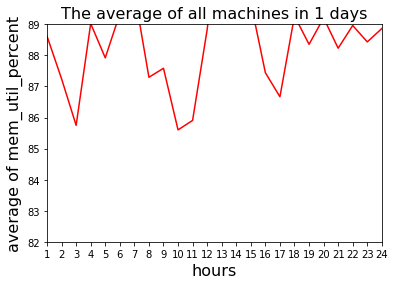

In [3]:
import numpy as np
import pandas as pd
from pandas import Series,DataFrame
import matplotlib.pyplot as plt

file_path='E:/google/days.csv'
s=pd.read_csv(file_path)
df=s.iloc[:,1].values.tolist()
dc=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 
    19, 20, 21, 22, 23, 24]
plt.plot(dc, df, c='red')

plt.title("The average of all machines in 1 days",fontsize=16)
plt.xlabel("hours",fontsize=16)
plt.ylabel("average of mem_util_percent",fontsize=16)
plt.axis([1,24,82,89])
plt.xticks(range(1,25,1))
plt.show()

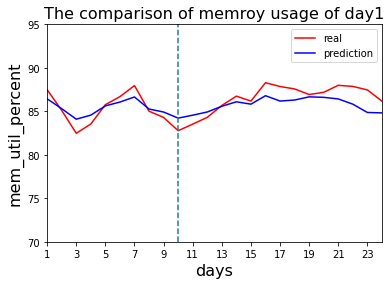

In [19]:
import numpy as np
import pandas as pd
from pandas import Series,DataFrame
import matplotlib.pyplot as plt

df=[87.48495318,85.10523362,82.47687239,83.54364288,85.76580588,
    86.68936905,87.96041973,85.01649955,84.29982583,82.77397794,
    83.52752786,84.30854449,85.67381081,86.74741831,86.18031121,
    88.29185973,87.85475969,87.57495596,86.93257869,87.18646152,
    87.99249124,87.86705623,87.46062141,86.17286726]
dw=[86.43724,85.306854,84.09586,84.56478,85.62669,86.06827,86.65083,
    85.26389,84.91917,84.22179,84.55739,84.92332,85.58223,86.09562,
    85.82616,86.79621,86.182434,86.30037,86.66502,86.609344,86.42616,
    85.822586,84.86987,84.821304]
dc=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 
    20, 21, 22, 23, 24]
plt.plot(dc, df, c='red',label='real')
plt.plot(dc, dw, c='blue',label='prediction')
plt.title("The comparison of memroy usage of day1",fontsize=16)
plt.xlabel("days",fontsize=16)
plt.ylabel("mem_util_percent",fontsize=16)
plt.axis([1,24,0,100])
#y轴进一步的限定条件
plt.ylim((70, 95))
plt.legend()
#x轴进一步的限定条件
plt.xticks(range(1,25,2))
#辅助线
plt.axvline(10, linestyle='--')
plt.show()


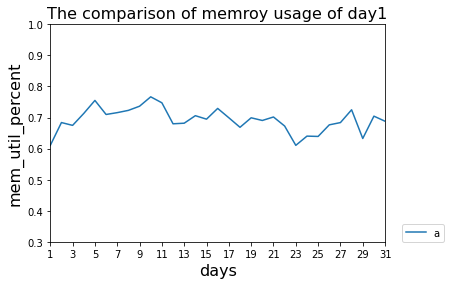

In [3]:
import numpy as np
import pandas as pd
from pandas import Series,DataFrame
import matplotlib.pyplot as plt

file_path='E:/google/data.csv'
s=pd.read_csv(file_path)
d1=s.iloc[:,1].values.tolist()
dc=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 
    20, 21, 22, 23, 24,25,26,27,28,29,30,31]
plt.plot(dc, d1,label='a')
#plt.plot(dc, d2,label='b')
#plt.plot(dc, d3,label='c')
#plt.plot(dc, d4,label='d')
#plt.plot(dc, d5,label='e')
#plt.plot(dc, d6,label='f')
#plt.plot(dc, d7,label='g')
#plt.plot(dc, d8,label='h')
plt.title("The comparison of memroy usage of day1",fontsize=16)
plt.xlabel("days",fontsize=16)
plt.ylabel("mem_util_percent",fontsize=16)
plt.axis([1,31,0,1])
#y轴进一步的限定条件
plt.ylim((0.3, 1))
#x轴进一步的限定条件
plt.xticks(range(1,32,2))
num1 = 1.05
num2 = 0
num3 = 3
num4 = 0
plt.legend(bbox_to_anchor=(num1, num2), loc=num3, borderaxespad=num4)
#辅助线
#plt.axvline(10, linestyle='--')
plt.show()

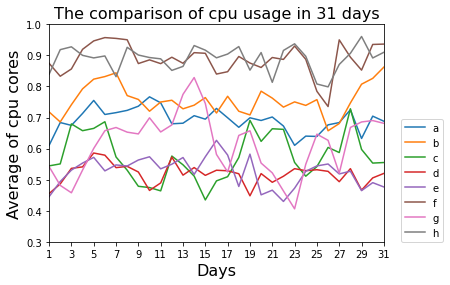

In [6]:
import numpy as np
import pandas as pd
from pandas import Series,DataFrame
import matplotlib.pyplot as plt

file_path='E:/google/data2.csv'
s=pd.read_csv(file_path)
d1=s.iloc[:,1].values.tolist()
d2=s.iloc[:,2].values.tolist()
d3=s.iloc[:,3].values.tolist()
d4=s.iloc[:,4].values.tolist()
d5=s.iloc[:,5].values.tolist()
d6=s.iloc[:,6].values.tolist()
d7=s.iloc[:,7].values.tolist()
d8=s.iloc[:,8].values.tolist()
dc=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 
    20, 21, 22, 23, 24,25,26,27,28,29,30,31]
plt.plot(dc, d1,label='a')
plt.plot(dc, d2,label='b')
plt.plot(dc, d3,label='c')
plt.plot(dc, d4,label='d')
plt.plot(dc, d5,label='e')
plt.plot(dc, d6,label='f')
plt.plot(dc, d7,label='g')
plt.plot(dc, d8,label='h')
plt.title("The comparison of cpu usage in 31 days",fontsize=16)
plt.xlabel("Days",fontsize=16)
plt.ylabel("Average of cpu cores",fontsize=16)
plt.axis([1,31,0.3,1])
#y轴进一步的限定条件
#plt.ylim((0.3, 1))
#x轴进一步的限定条件
plt.xticks(range(1,32,2))
num1 = 1.05
num2 = 0
num3 = 3
num4 = 0
plt.legend(bbox_to_anchor=(num1, num2), loc=num3, borderaxespad=num4)
#辅助线
#plt.axvline(10, linestyle='--')
plt.show()

In [4]:
for index in range(1815000000000,1901400000000,3600000000):
    print(index)

1815000000000
1818600000000
1822200000000
1825800000000
1829400000000
1833000000000
1836600000000
1840200000000
1843800000000
1847400000000
1851000000000
1854600000000
1858200000000
1861800000000
1865400000000
1869000000000
1872600000000
1876200000000
1879800000000
1883400000000
1887000000000
1890600000000
1894200000000
1897800000000


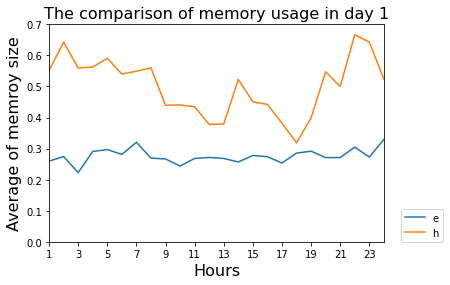

In [26]:
import numpy as np
import pandas as pd
from pandas import Series,DataFrame
import matplotlib.pyplot as plt

file_path='E:/google/data3.csv'
s=pd.read_csv(file_path)
d1=s.iloc[:,1].values.tolist()
d2=s.iloc[:,2].values.tolist()
dc=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 
    20, 21, 22, 23, 24]

plt.plot(dc, d1,label='e')
plt.plot(dc, d2,label='h')
plt.title("The comparison of memory usage in day 1",fontsize=16)
plt.xlabel("Hours",fontsize=16)
plt.ylabel("Average of memroy size",fontsize=16)
plt.axis([1,24,0,0.7])
#y轴进一步的限定条件
#plt.ylim((0.3, 1))
#x轴进一步的限定条件
plt.xticks(range(1,25,2))
num1 = 1.05
num2 = 0
num3 = 3
num4 = 0
plt.legend(bbox_to_anchor=(num1, num2), loc=num3, borderaxespad=num4)
#辅助线
#plt.axvline(14, linestyle='--')
#plt.axvline(10, linestyle='--')
plt.show()

       value
0   9.390339
1  11.605460
2  10.434350
3  10.809428
4   7.510783


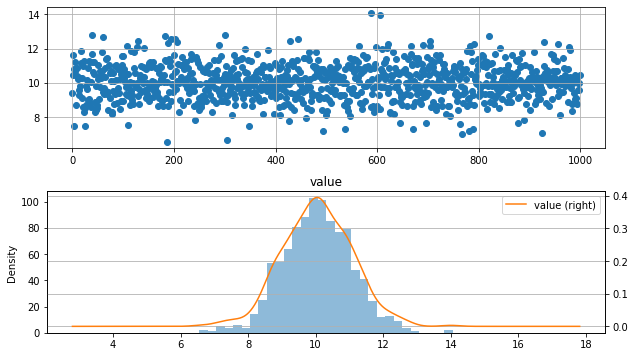

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


s = pd.DataFrame(np.random.randn(1000)+10,columns = ['value'])
print(s.head())
# 创建随机数据

fig = plt.figure(figsize = (10,6))
ax1 = fig.add_subplot(2,1,1)  # 创建子图1
ax1.scatter(s.index, s.values)
plt.grid()
# 绘制数据分布图

ax2 = fig.add_subplot(2,1,2)  # 创建子图2
s.hist(bins=30,alpha = 0.5,ax = ax2)
s.plot(kind = 'kde', secondary_y=True,ax = ax2)
plt.grid()
# 绘制直方图
# 呈现较明显的正太性


In [1]:
for x in range(600000000,2679000000000,3600000000) :
    print(x)

600000000
4200000000
7800000000
11400000000
15000000000
18600000000
22200000000
25800000000
29400000000
33000000000
36600000000
40200000000
43800000000
47400000000
51000000000
54600000000
58200000000
61800000000
65400000000
69000000000
72600000000
76200000000
79800000000
83400000000
87000000000
90600000000
94200000000
97800000000
101400000000
105000000000
108600000000
112200000000
115800000000
119400000000
123000000000
126600000000
130200000000
133800000000
137400000000
141000000000
144600000000
148200000000
151800000000
155400000000
159000000000
162600000000
166200000000
169800000000
173400000000
177000000000
180600000000
184200000000
187800000000
191400000000
195000000000
198600000000
202200000000
205800000000
209400000000
213000000000
216600000000
220200000000
223800000000
227400000000
231000000000
234600000000
238200000000
241800000000
245400000000
249000000000
252600000000
256200000000
259800000000
263400000000
267000000000
270600000000
274200000000
277800000000
281400000000
28500